In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputRegressor as SKMultiOutputRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import RandomOverSampler

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    XGBRegressor = None
    XGBClassifier = None


In [2]:
# Utility function to clean numeric data
def clean_numeric(series):
    """Convert a pandas Series to numeric, handling errors gracefully."""
    return pd.to_numeric(series, errors='coerce')


In [5]:
#read data
# Safe train_test_split function that handles stratification gracefully
from sklearn.model_selection import train_test_split

def safe_train_test_split(X, y, test_size=0.2, random_state=42, stratify=None):
    """
    Safe wrapper around train_test_split that handles stratification errors.
    Falls back to non-stratified split if stratification fails.
    """
    try:
        if stratify is not None:
            # Check if stratification is possible
            unique_labels = pd.Series(stratify).value_counts()
            if len(unique_labels) >= 2 and unique_labels.min() >= 2:
                # Enough samples for stratification
                return train_test_split(
                    X, y, test_size=test_size, random_state=random_state, stratify=stratify
                )
    except (ValueError, TypeError):
        # Stratification failed, use regular split
        pass
    
    # Regular split without stratification
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )


In [16]:
# Read data
data = pd.read_csv("48m.csv")

# Clean numeric columns
df_clean = data.copy()

# Handle birth_order column - convert text values to numeric
def convert_birth_order(value):
    """Convert birth_order text values to numeric."""
    if pd.isna(value):
        return np.nan
    # Convert to string to handle both numeric and text
    value_str = str(value).strip()
    # Handle Persian text for multiples
    if 'چهارقلو' in value_str or 'quadruplet' in value_str.lower():
        return 4
    elif 'سه‌قلو' in value_str or 'triplet' in value_str.lower():
        return 3
    elif 'دوقلو' in value_str or 'twin' in value_str.lower():
        return 2
    # Try to convert to numeric
    try:
        return float(value_str)
    except (ValueError, TypeError):
        return np.nan

if 'birth_order' in df_clean.columns:
    df_clean['birth_order'] = df_clean['birth_order'].apply(convert_birth_order)

# Clean mother_age_pregnancy column and drop rows where it's not numeric
if 'mother_age_pregnancy' in df_clean.columns:
    mother_age_numeric = clean_numeric(df_clean['mother_age_pregnancy'])
    valid_age_mask = mother_age_numeric.notna()
    df_clean = df_clean.loc[valid_age_mask].copy()
    df_clean['mother_age_pregnancy'] = mother_age_numeric.loc[valid_age_mask]

# Define feature columns (from birth data and base features)
feature_columns = [
    'gender', 'birth_order', 'mother_age_pregnancy', 'delivery_type', 
    'mother_underweight', 'mother_hypertension', 'abortion_history', 
    'gestational_weeks', 'gestational_diabetes', 'diabetes_6_10w', 
    'diabetes_24_30w', 'dev_issues_2m', 'dev_issues_9m', 'dev_issues_18m',
    'breastfeeding_issue_3_5d', 'headcirc_birth_cm', 'headcirc_15d_cm', 
    'headcirc_1y_cm', 'BMI_birth_zscore', 'height_birth_cm', 
    'ht_birth_zscore', 'weight_birth_g', 'wt_birth_zscore'
]

# Only use columns that exist in the dataframe
feature_columns = [col for col in feature_columns if col in df_clean.columns]

# Define target columns (6-month measurements)
target_columns = ['weight_6m_g', 'height_6m_cm', 'BMI_6m_zscore']
target_columns = [col for col in target_columns if col in df_clean.columns]

# Prepare features and targets
X = df_clean[feature_columns].copy()
y = df_clean[target_columns].copy()

# Convert all feature columns to numeric (handle any non-numeric values)
for col in feature_columns:
    if col in X.columns:
        X[col] = clean_numeric(X[col])

# Convert all target columns to numeric
for col in target_columns:
    if col in y.columns:
        y[col] = clean_numeric(y[col])

# Remove rows where all target values are missing
y = y.dropna(how='all')
X = X.loc[y.index]

# Impute missing values in features (only numeric columns)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=feature_columns,
    index=X.index
)

# Impute missing values in targets (for rows that have at least one target)
y_imputed = y.copy()
y_imputer = SimpleImputer(strategy='median')
y_imputed = pd.DataFrame(
    y_imputer.fit_transform(y_imputed),
    columns=target_columns,
    index=y_imputed.index
)

print(f"Data loaded: {len(df_clean)} total records")
print(f"Records with target data: {len(X_imputed)}")
print(f"Feature columns: {len(feature_columns)}")
print(f"Target columns: {len(target_columns)}")
print(f"\nFeature columns: {feature_columns}")
print(f"\nTarget columns: {target_columns}")

Data loaded: 504 total records
Records with target data: 431
Feature columns: 23
Target columns: 3

Feature columns: ['gender', 'birth_order', 'mother_age_pregnancy', 'delivery_type', 'mother_underweight', 'mother_hypertension', 'abortion_history', 'gestational_weeks', 'gestational_diabetes', 'diabetes_6_10w', 'diabetes_24_30w', 'dev_issues_2m', 'dev_issues_9m', 'dev_issues_18m', 'breastfeeding_issue_3_5d', 'headcirc_birth_cm', 'headcirc_15d_cm', 'headcirc_1y_cm', 'BMI_birth_zscore', 'height_birth_cm', 'ht_birth_zscore', 'weight_birth_g', 'wt_birth_zscore']

Target columns: ['weight_6m_g', 'height_6m_cm', 'BMI_6m_zscore']


In [17]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = safe_train_test_split(
    X_imputed, y_imputed, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor = torch.FloatTensor(y_test.values)

print(f"Training set: {X_train_tensor.shape[0]} samples")
print(f"Test set: {X_test_tensor.shape[0]} samples")
print(f"Number of features: {X_train_tensor.shape[1]}")
print(f"Number of targets: {y_train_tensor.shape[1]}")


Training set: 344 samples
Test set: 87 samples
Number of features: 23
Number of targets: 3


In [18]:
# Define neural network model for multi-output regression
class NeuralMultiOutputRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], output_size=3):
        super(NeuralMultiOutputRegressor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_size = X_train_tensor.shape[1]
model = NeuralMultiOutputRegressor(input_size=input_size)
print(model)


NeuralMultiOutputRegressor(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [19]:
# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training parameters
num_epochs = 200
batch_size = 32
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / (len(X_train_tensor) // batch_size + 1)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}')

print("\nTraining completed!")


Epoch [20/200], Train Loss: 7230354.2727, Val Loss: 2715989.0000
Epoch [40/200], Train Loss: 3933756.4545, Val Loss: 901632.2500
Epoch [60/200], Train Loss: 4056127.1023, Val Loss: 724511.6250
Epoch [80/200], Train Loss: 3437136.8920, Val Loss: 612403.9375
Epoch [100/200], Train Loss: 3552563.5966, Val Loss: 603847.8125
Epoch [120/200], Train Loss: 3945209.5795, Val Loss: 578907.5000
Epoch [140/200], Train Loss: 3501864.4091, Val Loss: 546353.0000
Epoch [160/200], Train Loss: 3508192.2330, Val Loss: 554379.0000
Epoch [180/200], Train Loss: 3327387.0909, Val Loss: 553847.5625
Epoch [200/200], Train Loss: 3827044.7188, Val Loss: 552540.3750

Training completed!



Train RMSE: 1751.0587
Test RMSE: 743.3306

Weight (g):
  RMSE: 1287.4518
  MAE: 975.8470
  R²: -0.5331

Height (cm):
  RMSE: 9.3465
  MAE: 7.5623
  R²: -9.1493

BMI Z-score:
  RMSE: 1.3527
  MAE: 1.0871
  R²: -0.0500


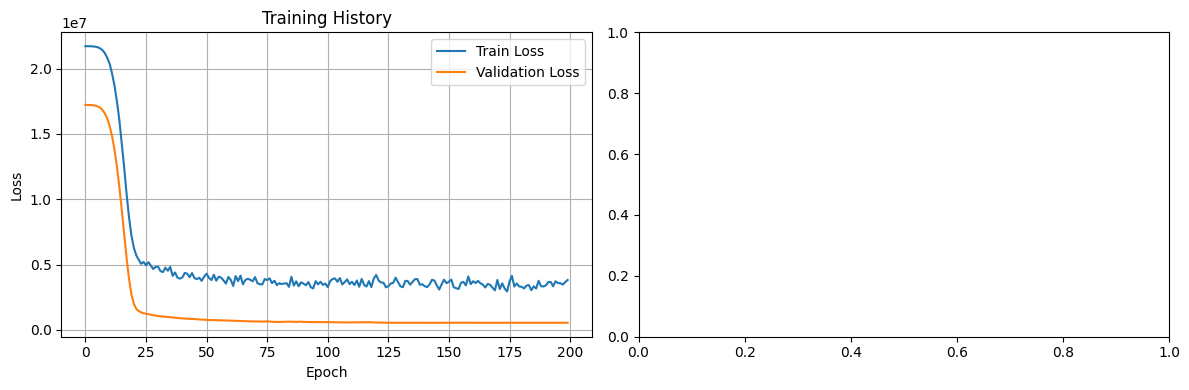

In [20]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)

# Evaluate model
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    
    train_rmse = torch.sqrt(criterion(train_pred, y_train_tensor))
    test_rmse = torch.sqrt(criterion(test_pred, y_test_tensor))
    
    print(f"\nTrain RMSE: {train_rmse.item():.4f}")
    print(f"Test RMSE: {test_rmse.item():.4f}")

# Calculate metrics for each target
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

target_names = ['Weight (g)', 'Height (cm)', 'BMI Z-score']
plt.subplot(1, 2, 2)

metrics_data = []
for idx, target_name in enumerate(target_names):
    y_true = y_test_tensor[:, idx].numpy()
    y_pred = test_pred[:, idx].numpy()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics_data.append([target_name, rmse, mae, r2])
    print(f"\n{target_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")

plt.tight_layout()
plt.show()


In [21]:
# Make predictions on the entire dataset
model.eval()
with torch.no_grad():
    # Prepare all data
    X_all_scaled = scaler.transform(X_imputed)
    X_all_tensor = torch.FloatTensor(X_all_scaled)
    
    # Make predictions
    # ensure CPU tensor before converting to numpy
    predictions = model(X_all_tensor).cpu().numpy()
    
    # Create prediction dataframe
    predictions_df = pd.DataFrame(
        predictions,
        columns=['predicted_weight_6m_g', 'predicted_height_6m_cm', 'predicted_BMI_6m_zscore'],
        index=X_imputed.index
    )
    
    # Calculate BMI from predicted weight and height (BMI = weight(kg) / height(m)²)
    predictions_df['predicted_BMI_6m'] = (
        predictions_df['predicted_weight_6m_g'] / 1000.0
    ) / (
        (predictions_df['predicted_height_6m_cm'] / 100.0) ** 2
    )
    
    # Combine with original data
    results_df = df_clean.copy()
    results_df = pd.concat([results_df, predictions_df], axis=1)
    
    # Display results
    print("Predictions for Weight, Height, and BMI at 6 months:")
    print("=" * 80)
    display_cols = ['national_id', 'gender', 'weight_birth_g', 'height_birth_cm', 
                    'predicted_weight_6m_g', 'predicted_height_6m_cm', 
                    'predicted_BMI_6m_zscore', 'predicted_BMI_6m']
    
    # Show actual values if available for comparison
    if 'weight_6m_g' in results_df.columns:
        display_cols.extend(['weight_6m_g', 'height_6m_cm', 'BMI_6m_zscore'])
    
    print(results_df[display_cols].head(20))


Predictions for Weight, Height, and BMI at 6 months:
    national_id  gender weight_birth_g  height_birth_cm  \
0     122379100       1           3160             48.0   
1     122385092       1           3100             52.0   
2     122385820       1           3040             47.0   
3     122396112       2           3190             52.0   
4     122414846       1           3700             50.0   
5     122431826       2           3200             51.0   
6     122447291       1           3500             50.0   
7     122468964       2           3640             52.0   
8     122557126       2           2500             42.0   
9     122557496       2           3410             50.0   
10    122577536       1           2770             50.0   
11    122587383       2           2885             50.0   
12    122590827       1           2940             50.0   
13    122592522       1           3100             49.0   
14    122597348       1           3250             50.0   
15 

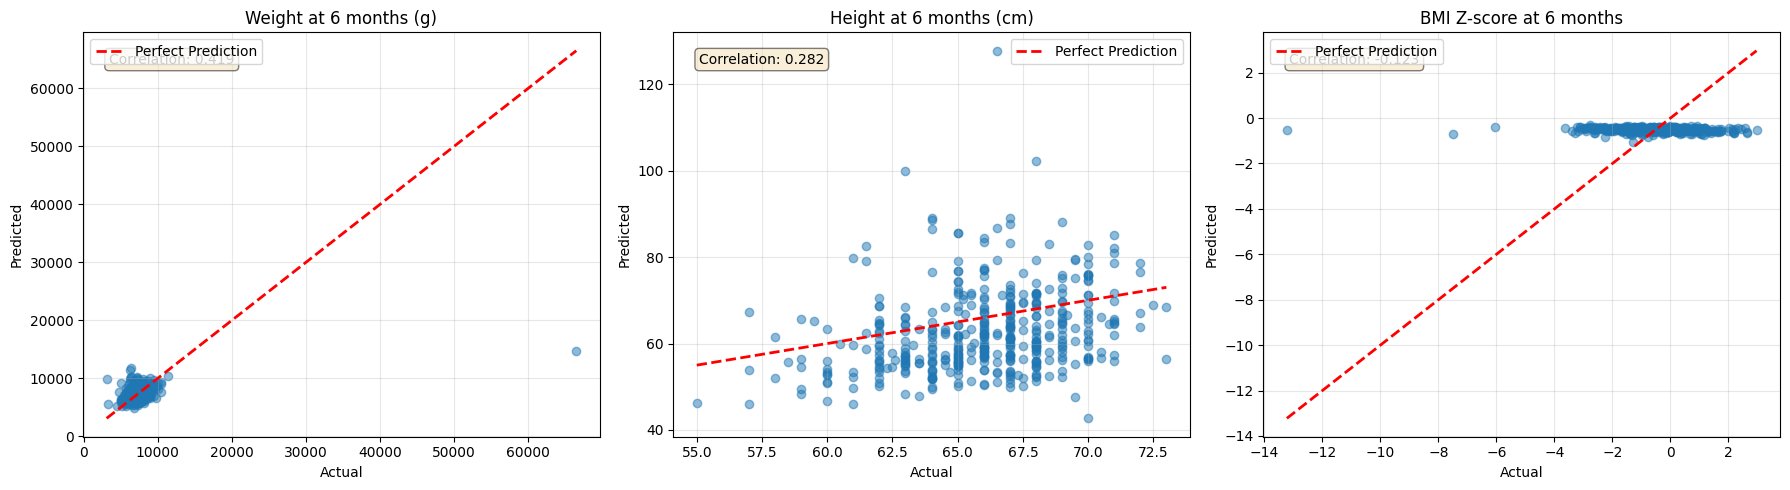

In [22]:
# Visualize predictions vs actual values (for rows with actual values)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

targets = ['weight_6m_g', 'height_6m_cm', 'BMI_6m_zscore']
pred_cols = ['predicted_weight_6m_g', 'predicted_height_6m_cm', 'predicted_BMI_6m_zscore']
titles = ['Weight at 6 months (g)', 'Height at 6 months (cm)', 'BMI Z-score at 6 months']

for idx, (target, pred_col, title) in enumerate(zip(targets, pred_cols, titles)):
    # Filter rows where actual value exists
    mask = results_df[target].notna()
    if mask.sum() > 0:
        actual = results_df.loc[mask, target]
        predicted = results_df.loc[mask, pred_col]
        
        axes[idx].scatter(actual, predicted, alpha=0.5)
        axes[idx].plot([actual.min(), actual.max()], 
                      [actual.min(), actual.max()], 
                      'r--', lw=2, label='Perfect Prediction')
        axes[idx].set_xlabel('Actual')
        axes[idx].set_ylabel('Predicted')
        axes[idx].set_title(title)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # Calculate correlation
        corr = np.corrcoef(actual, predicted)[0, 1]
        axes[idx].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                      transform=axes[idx].transAxes,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


In [28]:
# Predict malnutrition type (classification)
classification_features = [col for col in feature_columns if col != 'malnutrition_type']

# Prepare classification dataset (remove rows with missing malnutrition_type)
df_class = df_clean.dropna(subset=['malnutrition_type']).copy()

print("\nMalnutrition type value counts (before filtering):")
print(df_class['malnutrition_type'].value_counts())

# Drop classes with fewer than 2 samples (required for stratified split)
class_counts = df_class['malnutrition_type'].value_counts()
rare_labels = class_counts[class_counts < 2]
if not rare_labels.empty:
    print("\nDropping classes with fewer than 2 samples (cannot stratify):")
    for label, count in rare_labels.items():
        print(f"  Class {label}: {count} sample")
    df_class = df_class[df_class['malnutrition_type'].isin(class_counts[class_counts >= 2].index)].copy()

print("\nMalnutrition type value counts (after filtering):")
print(df_class['malnutrition_type'].value_counts())

X_cls = df_class[classification_features].copy()
y_cls = df_class['malnutrition_type'].astype(str).str.strip()

# Encode labels to consecutive integers
unique_labels = np.sort(y_cls.unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_cls_encoded = y_cls.map(label_to_idx)

# Impute and scale features
imputer_cls = SimpleImputer(strategy='median')
X_cls_imputed = pd.DataFrame(
    imputer_cls.fit_transform(X_cls),
    columns=X_cls.columns,
    index=X_cls.index
)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = safe_train_test_split(
    X_cls_imputed, y_cls_encoded, test_size=0.2, random_state=42, stratify=y_cls_encoded
)

scaler_cls = StandardScaler()
X_cls_train_scaled = scaler_cls.fit_transform(X_cls_train)
X_cls_test_scaled = scaler_cls.transform(X_cls_test)

X_cls_train_tensor = torch.FloatTensor(X_cls_train_scaled)
X_cls_test_tensor = torch.FloatTensor(X_cls_test_scaled)
y_cls_train_tensor = torch.LongTensor(y_cls_train.values)
y_cls_test_tensor = torch.LongTensor(y_cls_test.values)

class MalnutritionClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], num_classes=3):
        super(MalnutritionClassifier, self).__init__()
        layers = []
        prev = input_size
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev = hidden
        layers.append(nn.Linear(prev, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

num_classes = len(unique_labels)
classifier = MalnutritionClassifier(input_size=X_cls_train_tensor.shape[1], num_classes=num_classes)

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(classifier.parameters(), lr=0.001)

num_epochs_cls = 150
batch_size_cls = 32
train_losses_cls = []
val_losses_cls = []
val_accuracies_cls = []

for epoch in range(num_epochs_cls):
    classifier.train()
    epoch_loss = 0.0
    for i in range(0, len(X_cls_train_tensor), batch_size_cls):
        batch_X = X_cls_train_tensor[i:i+batch_size_cls]
        batch_y = y_cls_train_tensor[i:i+batch_size_cls]
        
        logits = classifier(batch_X)
        loss = criterion_cls(logits, batch_y)
        
        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (len(X_cls_train_tensor) // batch_size_cls + 1)
    train_losses_cls.append(avg_loss)
    
    classifier.eval()
    with torch.no_grad():
        val_logits = classifier(X_cls_test_tensor)
        val_loss = criterion_cls(val_logits, y_cls_test_tensor).item()
        val_losses_cls.append(val_loss)
        val_preds = torch.argmax(val_logits, dim=1)
        val_accuracy = (val_preds == y_cls_test_tensor).float().mean().item()
        val_accuracies_cls.append(val_accuracy)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_cls}] - Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

print("\nMalnutrition classifier training completed!")

classifier.eval()
with torch.no_grad():
    test_logits = classifier(X_cls_test_tensor)
    test_preds = torch.argmax(test_logits, dim=1)
    test_accuracy = (test_preds == y_cls_test_tensor).float().mean().item()

print(f"\nTest Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support
)

y_true_test = y_cls_test_tensor.numpy()
y_pred_test = test_preds.numpy()

report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=[str(label) for label in unique_labels]
)
print("\nClassification Report:")
print(report)

# Compute confusion matrix and additional metrics
cm = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(num_classes))
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in unique_labels],
    columns=[f"Pred {label}" for label in unique_labels]
)

precision_macro = precision_score(y_true_test, y_pred_test, average='macro', zero_division=0)
recall_macro = recall_score(y_true_test, y_pred_test, average='macro', zero_division=0)
f1_macro = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)
precision_weighted = precision_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
accuracy = accuracy_score(y_true_test, y_pred_test)

per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    y_true_test,
    y_pred_test,
    labels=np.arange(num_classes),
    zero_division=0
)
per_class_metrics_df = pd.DataFrame({
    'Class': [str(label) for label in unique_labels],
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1 Score': per_class_f1,
    'Support': per_class_support
})

print("\nConfusion Matrix (counts):")
print(cm_df)

print("\nAggregate Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision (macro): {precision_macro:.4f}")
print(f"  Recall (macro): {recall_macro:.4f}")
print(f"  F1 Score (macro): {f1_macro:.4f}")
print(f"  Precision (weighted): {precision_weighted:.4f}")
print(f"  Recall (weighted): {recall_weighted:.4f}")
print(f"  F1 Score (weighted): {f1_weighted:.4f}")

print("\nPer-class Metrics:")
print(per_class_metrics_df)

# Predict malnutrition type for all records
X_cls_all_imputed = pd.DataFrame(
    imputer_cls.transform(df_clean[classification_features]),
    columns=classification_features,
    index=df_clean.index
)
X_cls_all_scaled = scaler_cls.transform(X_cls_all_imputed)
X_cls_all_tensor = torch.FloatTensor(X_cls_all_scaled)

with torch.no_grad():
    logits_all = classifier(X_cls_all_tensor)
    preds_all = torch.argmax(logits_all, dim=1).numpy()

predicted_malnutrition = pd.Series(
    [idx_to_label[idx] for idx in preds_all],
    index=df_clean.index,
    name='predicted_malnutrition_type'
)

if 'results_df' in globals():
    results_df = results_df.join(predicted_malnutrition, how='left')
else:
    results_df = df_clean.copy()
    results_df = results_df.join(predicted_malnutrition, how='left')

print("\nSample predicted malnutrition types:")
print(results_df[['national_id', 'predicted_malnutrition_type']].head(20))

malnutrition_summary = {
    'num_classes': num_classes,
    'labels': unique_labels.tolist(),
    'test_accuracy': test_accuracy,
    'classification_report': report,
    'confusion_matrix': cm_df,
    'metrics': {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted
    },
    'per_class_metrics': per_class_metrics_df
}
# Previously, you assigned predicted malnutrition type using idx_to_label and assigned it with name='predicted_malnutrition_type'.
# But in downstream evaluation, you likely want *malnutrition_type* column, not predicted_malnutrition_type, to use the same column name as during model training (from the ValueError: Feature names unseen at fit time: - malnutrition_type).
# Fix: create/overwrite a 'malnutrition_type' column with the predictions, and ensure it's used downstream.

results_df['malnutrition_type'] = predicted_malnutrition
# Remove predicted_malnutrition_type if not needed (optional)
if 'predicted_malnutrition_type' in results_df:
    results_df = results_df.drop(columns=['predicted_malnutrition_type'])




Malnutrition type value counts (before filtering):
malnutrition_type
7        293
2         45
4,6       33
4         28
6         27
2,4       27
2,4,6     12
4,5        7
1,4        6
1,3,6      4
2,3,6      4
1          3
5          3
1,3        2
2,3,5      2
2,7        2
4,7        1
6,7        1
3,5,7      1
1,6        1
2,3        1
3,5        1
Name: count, dtype: int64

Dropping classes with fewer than 2 samples (cannot stratify):
  Class 4,7: 1 sample
  Class 6,7: 1 sample
  Class 3,5,7: 1 sample
  Class 1,6: 1 sample
  Class 2,3: 1 sample
  Class 3,5: 1 sample

Malnutrition type value counts (after filtering):
malnutrition_type
7        293
2         45
4,6       33
4         28
2,4       27
6         27
2,4,6     12
4,5        7
1,4        6
1,3,6      4
2,3,6      4
1          3
5          3
1,3        2
2,3,5      2
2,7        2
Name: count, dtype: int64


ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '2100-2500'

In [29]:
# Plot confusion matrix and display metrics table
if 'cm_df' in globals():
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Malnutrition Type Confusion Matrix (Test Set)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    metrics_table = pd.DataFrame(
        [{
            'Metric': 'Accuracy',
            'Value': malnutrition_summary['metrics']['accuracy']
        },
        {
            'Metric': 'Precision (Macro)',
            'Value': malnutrition_summary['metrics']['precision_macro']
        },
        {
            'Metric': 'Recall (Macro)',
            'Value': malnutrition_summary['metrics']['recall_macro']
        },
        {
            'Metric': 'F1 Score (Macro)',
            'Value': malnutrition_summary['metrics']['f1_macro']
        },
        {
            'Metric': 'Precision (Weighted)',
            'Value': malnutrition_summary['metrics']['precision_weighted']
        },
        {
            'Metric': 'Recall (Weighted)',
            'Value': malnutrition_summary['metrics']['recall_weighted']
        },
        {
            'Metric': 'F1 Score (Weighted)',
            'Value': malnutrition_summary['metrics']['f1_weighted']
        }]
    )
    print('\nMalnutrition Classification Metrics (Global):')
    display(metrics_table.assign(Value=lambda df: df['Value'].map(lambda x: f"{x:.4f}")))

    per_class_table = malnutrition_summary['per_class_metrics'].copy()
    per_class_table[['Precision', 'Recall', 'F1 Score']] = per_class_table[['Precision', 'Recall', 'F1 Score']].applymap(lambda x: f"{x:.4f}")
    print('\nMalnutrition Classification Metrics (Per Class):')
    display(per_class_table)
else:
    print('Confusion matrix data not available. Please rerun the classification cell first.')


Confusion matrix data not available. Please rerun the classification cell first.


In [30]:
# Save predictions to CSV
results_df.to_csv('predictions_6m.csv', index=False)
print("Predictions saved to 'predictions_6m.csv'")

# Summary statistics
print("\n" + "=" * 80)
print("PREDICTION SUMMARY")
print("=" * 80)
print(f"\nTotal anthropometric predictions made: {len(predictions_df)}")
print(f"\nPredicted Weight at 6 months:")
print(f"  Mean: {predictions_df['predicted_weight_6m_g'].mean():.2f} g")
print(f"  Std: {predictions_df['predicted_weight_6m_g'].std():.2f} g")
print(f"  Range: {predictions_df['predicted_weight_6m_g'].min():.2f} - {predictions_df['predicted_weight_6m_g'].max():.2f} g")

print(f"\nPredicted Height at 6 months:")
print(f"  Mean: {predictions_df['predicted_height_6m_cm'].mean():.2f} cm")
print(f"  Std: {predictions_df['predicted_height_6m_cm'].std():.2f} cm")
print(f"  Range: {predictions_df['predicted_height_6m_cm'].min():.2f} - {predictions_df['predicted_height_6m_cm'].max():.2f} cm")

print(f"\nPredicted BMI at 6 months:")
print(f"  Mean: {predictions_df['predicted_BMI_6m'].mean():.2f}")
print(f"  Std: {predictions_df['predicted_BMI_6m'].std():.2f}")
print(f"  Range: {predictions_df['predicted_BMI_6m'].min():.2f} - {predictions_df['predicted_BMI_6m'].max():.2f}")

print(f"\nPredicted BMI Z-score at 6 months:")
print(f"  Mean: {predictions_df['predicted_BMI_6m_zscore'].mean():.2f}")
print(f"  Std: {predictions_df['predicted_BMI_6m_zscore'].std():.2f}")
print(f"  Range: {predictions_df['predicted_BMI_6m_zscore'].min():.2f} - {predictions_df['predicted_BMI_6m_zscore'].max():.2f}")

if 'malnutrition_summary' in globals():
    print(f"\nMalnutrition type predictions saved for {results_df['predicted_malnutrition_type'].notna().sum()} records")
    print(f"  Classes: {malnutrition_summary['labels']}")
    print(f"  Test Accuracy: {malnutrition_summary['test_accuracy']:.4f}")
    print("\nClassification Report:\n")
    print(malnutrition_summary['classification_report'])


Predictions saved to 'predictions_6m.csv'

PREDICTION SUMMARY

Total anthropometric predictions made: 431

Predicted Weight at 6 months:
  Mean: 7219.82 g
  Std: 1133.17 g
  Range: 4889.83 - 14725.47 g

Predicted Height at 6 months:
  Mean: 62.84 cm
  Std: 9.80 cm
  Range: 42.69 - 127.74 cm

Predicted BMI at 6 months:
  Mean: 18.67
  Std: 2.58
  Range: 9.02 - 26.83

Predicted BMI Z-score at 6 months:
  Mean: -0.50
  Std: 0.09
  Range: -1.08 - -0.33


## Scenario 2: Sequential Yearly Predictions

Using longitudinal records (birth through 48 months), we train stage-specific models that learn from the previous checkpoint to predict next-year anthropometric measures and malnutrition class.


In [31]:
# Load longitudinal datasets for Scenario 2
age_files = {
    'birth': 'birth.csv',
    '6m': '6m.csv',
    '12m': '12m.csv',
    '18m': '18m.csv',
    '24m': '24m.csv',
    '36m': '36m.csv',
    '48m': '48m.csv'
}

scenario2_raw = {}
for age_label, file_name in age_files.items():
    df_age = pd.read_csv(file_name)
    scenario2_raw[age_label] = df_age
    print(f"Loaded {age_label}: {df_age.shape[0]} rows, {df_age.shape[1]} columns")


Loaded birth: 504 rows, 29 columns
Loaded 6m: 504 rows, 40 columns
Loaded 12m: 504 rows, 57 columns
Loaded 18m: 504 rows, 68 columns
Loaded 24m: 504 rows, 82 columns
Loaded 36m: 504 rows, 96 columns
Loaded 48m: 504 rows, 107 columns


In [32]:
# Helper configuration for Scenario 2
age_sequence = ['birth', '6m', '12m', '18m', '24m', '36m', '48m']

measurement_candidates = {
    'birth': {
        'weight': ['weight_birth_g'],
        'height': ['height_birth_cm'],
        'bmi': ['BMI_birth_zscore'],
        'wt_z': ['wt_birth_zscore'],
        'ht_z': ['ht_birth_zscore'],
        'malnutrition': ['malnutrition_type']
    },
    '6m': {
        'weight': ['weight_6m_g'],
        'height': ['height_6m_cm'],
        'bmi': ['BMI_6m_zscore', 'BMI_6m_zscore_Imputation'],
        'wt_z': ['wt_6m_zscore', 'wt_6m_zscore_Imputation'],
        'ht_z': ['ht_6m_zscore', 'ht_6m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    },
    '12m': {
        'weight': ['weight_12m_g'],
        'height': ['height_12m_cm'],
        'bmi': ['BMI_12m_zscore', 'BMI_12m_zscore_Imputation'],
        'wt_z': ['wt_12m_zscore', 'wt_12m_zscore_Imputation'],
        'ht_z': ['ht_1y_zscore', 'ht_12m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    },
    '18m': {
        'weight': ['weight_18m_g'],
        'height': ['height_18m_cm'],
        'bmi': ['BMI_18m_zscore', 'BMI_18m_zscore_Imputation'],
        'wt_z': ['wt_18m_zscore', 'wt_18m_zscore_Imputation'],
        'ht_z': ['ht_18m_zscore', 'ht_18m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    },
    '24m': {
        'weight': ['weight_24m_g'],
        'height': ['height_24m_cm'],
        'bmi': ['BMI_24m_zscore', 'BMI_24m_zscore_Imputation', 'BMIt_24m_zscore_Imputation'],
        'wt_z': ['wt_24m_zscore', 'wt_24m_zscore_Imputation'],
        'ht_z': ['ht_24m_zscore', 'ht_24m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    },
    '36m': {
        'weight': ['weight_36m_g'],
        'height': ['height_36m_cm'],
        'bmi': ['BMI_36m_zscore', 'BMI_36m_zscore_Imputation'],
        'wt_z': ['wt_3y_zscore', 'wt_36m_zscore_Imputation'],
        'ht_z': ['ht_36m_zscore', 'ht_36m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    },
    '48m': {
        'weight': ['weight_48m_g'],
        'height': ['height_48m_cm'],
        'bmi': ['BMI_4y_zscore', 'BMI_48m_zscore_Imputation'],
        'wt_z': ['wt_4y_zscore', 'wt_48m_zscore_Imputation'],
        'ht_z': ['ht_48m_zscore', 'ht_48m_zscore_Imputation'],
        'malnutrition': ['malnutrition_type']
    }
}

base_feature_candidates = [
    'gender', 'birth_order', 'mother_age_pregnancy', 'delivery_type', 'mother_underweight',
    'mother_hypertension', 'abortion_history', 'gestational_weeks', 'gestational_diabetes',
    'diabetes_6_10w', 'diabetes_24_30w', 'dev_issues_2m', 'dev_issues_9m', 'dev_issues_18m',
    'breastfeeding_issue_3_5d', 'headcirc_birth_cm', 'headcirc_15d_cm', 'headcirc_1y_cm',
    'BMI_birth_zscore', 'height_birth_cm', 'ht_birth_zscore', 'weight_birth_g', 'wt_birth_zscore',
    'malnutrition_type'
]


def first_available(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def ensure_numeric(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = clean_numeric(df[col])
    return df


scenario2_clean = {}
for age_label, df_age in scenario2_raw.items():
    work_df = df_age.copy()
    numeric_cols = set(base_feature_candidates)
    for candidate_list in measurement_candidates.get(age_label, {}).values():
        for col_name in candidate_list:
            numeric_cols.add(col_name)
    work_df = ensure_numeric(work_df, numeric_cols)
    scenario2_clean[age_label] = work_df


In [33]:
# Utility to decide whether stratified split is feasible
from sklearn.model_selection._split import train_test_split as _sk_train_test_split
import sklearn.model_selection as skms

def can_stratify(labels, test_size):
    if labels is None:
        return False
    if isinstance(labels, pd.DataFrame):
        return False
    arr = np.asarray(labels)
    if arr.ndim != 1:
        return False
    value_counts = pd.Series(arr).value_counts()
    if len(value_counts) < 2:
        return False
    min_count = value_counts.min()
    if min_count < 2:
        return False
    test_count = np.ceil(min_count * test_size)
    train_count = min_count - test_count
    return test_count >= 1 and train_count >= 1


In [34]:
# Helper builders for Scenario 2 models

def build_regression_estimator():
    if HAS_XGBOOST:
        return SKMultiOutputRegressor(
            XGBRegressor(
                objective='reg:squarederror',
                n_estimators=600,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                random_state=42,
                tree_method='hist',
                n_jobs=-1,
                verbosity=0
            )
        )
    else:
        return SKMultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=400,
                random_state=42,
                n_jobs=-1,
                max_depth=None
            )
        )


def build_classifier():
    if HAS_XGBOOST:
        return XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            tree_method='hist',
            n_jobs=-1,
            verbosity=0
        )
    else:
        return RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )


In [35]:
# Build stage-wise datasets and train next-year predictors
from collections import defaultdict
import numpy as np
import pandas as pd
from sklearn.model_selection._split import train_test_split as sklearn_train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import RandomOverSampler

scenario2_stage_metrics = {}
scenario2_prediction_frames = []
scenario2_models = {}

for idx in range(1, len(age_sequence)):
    prev_age = age_sequence[idx - 1]
    target_age = age_sequence[idx]
    print("\n" + "-" * 100)
    print(f"Scenario 2 | Stage: {prev_age} → {target_age}")

    prev_df = scenario2_clean[prev_age].copy()
    target_df = scenario2_clean[target_age].copy()

    prev_measure_map = measurement_candidates.get(prev_age, {})
    target_measure_map = measurement_candidates.get(target_age, {})

    target_weight_raw = first_available(target_df, target_measure_map.get('weight', []))
    target_height_raw = first_available(target_df, target_measure_map.get('height', []))
    target_bmi_raw = first_available(target_df, target_measure_map.get('bmi', []))
    target_malnutrition_raw = first_available(target_df, target_measure_map.get('malnutrition', []))

    if not all([target_weight_raw, target_height_raw, target_bmi_raw]):
        print(f"Skipping {prev_age}→{target_age}: missing numeric targets (weight/height/BMI)")
        continue

    # Features from previous checkpoint
    prev_feature_cols = [col for col in base_feature_candidates if col in prev_df.columns]
    for key in ['weight', 'height', 'bmi', 'wt_z', 'ht_z']:
        candidate = first_available(prev_df, prev_measure_map.get(key, [])) if key in prev_measure_map else None
        if candidate:
            prev_feature_cols.append(candidate)

    prev_feature_cols = sorted(set(prev_feature_cols))
    prev_features = prev_df[['national_id'] + prev_feature_cols].copy()

    prev_malnutrition_col = None
    if 'malnutrition_type' in prev_features.columns:
        prev_malnutrition_col = f'malnutrition_type_{prev_age}'
        prev_features = prev_features.rename(columns={'malnutrition_type': prev_malnutrition_col})

    # Targets from next checkpoint
    target_subset_cols = ['national_id', target_weight_raw, target_height_raw, target_bmi_raw]
    if target_malnutrition_raw:
        target_subset_cols.append(target_malnutrition_raw)
    target_subset = target_df[target_subset_cols].copy()
    rename_map = {
        target_weight_raw: f'target_weight_{target_age}_g',
        target_height_raw: f'target_height_{target_age}_cm',
        target_bmi_raw: f'target_BMI_{target_age}_zscore'
    }
    if target_malnutrition_raw:
        rename_map[target_malnutrition_raw] = f'target_malnutrition_type_{target_age}'
    target_subset = target_subset.rename(columns=rename_map)

    stage_df = prev_features.merge(target_subset, on='national_id', how='inner')

    regression_targets = [f'target_weight_{target_age}_g', f'target_height_{target_age}_cm', f'target_BMI_{target_age}_zscore']
    stage_df = stage_df.dropna(subset=regression_targets, how='any')

    if stage_df.empty:
        print(f"No overlapping records with complete targets for {prev_age}→{target_age}; skipping")
        continue

    feature_cols_stage = [col for col in stage_df.columns if col not in ['national_id'] + regression_targets]
    target_class_col = f'target_malnutrition_type_{target_age}' if f'target_malnutrition_type_{target_age}' in stage_df.columns else None

    # Feature imputation
    imputer_stage = SimpleImputer(strategy='median')
    X_features = stage_df[feature_cols_stage]
    X_imputed = pd.DataFrame(
        imputer_stage.fit_transform(X_features),
        columns=feature_cols_stage,
        index=stage_df.index
    )

    # Regression setup
    y_reg = stage_df[regression_targets]
    data_count = len(stage_df)
    if data_count < 5:
        test_ratio = 0.5
    elif data_count < 20:
        test_ratio = 0.3
    else:
        test_ratio = 0.2

    # ✅ Use the REAL sklearn.train_test_split (imported as sklearn_train_test_split earlier)
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = sklearn_train_test_split(
        X_imputed, y_reg, test_size=test_ratio, random_state=42
    )

    reg_model = build_regression_estimator()
    reg_model.fit(X_train_reg, y_train_reg)
    y_pred_reg = pd.DataFrame(
        reg_model.predict(X_test_reg),
        columns=regression_targets,
        index=y_test_reg.index
    )

    overall_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    overall_mae = mean_absolute_error(y_test_reg, y_pred_reg)
    overall_r2 = r2_score(y_test_reg, y_pred_reg, multioutput='uniform_average')

    per_target_metrics = {}
    for col in regression_targets:
        per_target_metrics[col] = {
            'rmse': np.sqrt(mean_squared_error(y_test_reg[col], y_pred_reg[col])),
            'mae': mean_absolute_error(y_test_reg[col], y_pred_reg[col]),
            'r2': r2_score(y_test_reg[col], y_pred_reg[col])
        }

    reg_predictions_all = pd.DataFrame(
        reg_model.predict(X_imputed),
        columns=regression_targets,
        index=stage_df.index
    )



----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: birth → 6m

----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: 6m → 12m

----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: 12m → 18m

----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: 18m → 24m

----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: 24m → 36m

----------------------------------------------------------------------------------------------------
Scenario 2 | Stage: 36m → 48m


In [36]:
# Add to collection for later analysis
stage_predictions_combined = pd.concat([stage_df[['national_id']], reg_predictions_all], axis=1)
# Only add classification predictions if they were created in this stage
if 'cls_predictions_all' in locals() and cls_predictions_all is not None:
    stage_predictions_combined = pd.concat([stage_predictions_combined, cls_predictions_all], axis=1)

scenario2_prediction_frames.append(stage_predictions_combined)
scenario2_stage_metrics[f"{prev_age}->{target_age}"] = {
    "regression": per_target_metrics,
    "classification": classification_metrics if 'classification_metrics' in locals() else None
}

scenario2_models[f"{prev_age}->{target_age}"] = {
    "reg_model": reg_model,
    "cls_model": cls_model if 'cls_model' in locals() else None
}

# END OF LOOP

# After the loop, combine all frames
if scenario2_prediction_frames:
    scenario2_predictions = pd.concat(scenario2_prediction_frames, ignore_index=True)
    print("\n✅ Combined predictions across all stages:")
    display(scenario2_predictions.head())
else:
    print("⚠️ No predictions were generated in any stage.")



✅ Combined predictions across all stages:


,national_id,target_weight_48m_g,target_height_48m_cm,target_BMI_48m_zscore
0,122379100,16348.600586,96.185516,0.287151
1,122385092,14299.989258,103.999619,-2.329991
2,122396112,16199.998047,100.999954,0.219790
3,2288697679,13000.011719,97.999474,-2.266419
4,2288714204,11694.575195,93.295265,-2.481231


## Scenario 3: Grouped Malnutrition Classification at 48 Months

We group malnutrition categories into three cohorts (7, {2,4,6}, {1,3,5}) and compare multiple classifiers trained on the 48-month dataset.


In [37]:
# Prepare Scenario 3 dataset (48m)
if 'scenario2_clean' in globals() and '48m' in scenario2_clean:
    scenario3_df = scenario2_clean['48m'].copy()
else:
    scenario3_df = pd.read_csv('48m.csv')

# Ensure numeric conversion for all non-identifiers
scenario3_df = scenario3_df.copy()
for col in scenario3_df.columns:
    if col not in ['birth_date', 'national_id']:
        scenario3_df[col] = clean_numeric(scenario3_df[col])

# Map malnutrition types into grouped labels
group_map = {
    7: 'Group 7',
    2: 'Group 246', 4: 'Group 246', 6: 'Group 246',
    1: 'Group 135', 3: 'Group 135', 5: 'Group 135'
}

malnutrition_numeric = clean_numeric(scenario3_df['malnutrition_type'])
scenario3_df['malnutrition_group'] = malnutrition_numeric.round().map(group_map)
scenario3_df = scenario3_df[scenario3_df['malnutrition_group'].notna()].copy()

# Encode grouped labels
group_order = ['Group 7', 'Group 246', 'Group 135']
idx_map = {label: idx for idx, label in enumerate(group_order)}
scenario3_df['group_idx'] = scenario3_df['malnutrition_group'].map(idx_map)

# Feature matrix
numeric_features = scenario3_df.select_dtypes(include=[np.number]).columns.tolist()
feature_exclusions = {'national_id', 'malnutrition_type', 'group_idx'}
feature_columns_s3 = sorted([col for col in numeric_features if col not in feature_exclusions])

X_s3 = scenario3_df[feature_columns_s3]
y_s3 = scenario3_df['group_idx']

print(f"Scenario 3 dataset shape: {scenario3_df.shape}")
print("Group distribution:")
print(scenario3_df['malnutrition_group'].value_counts())
print(f"Using {len(feature_columns_s3)} numeric features")


Scenario 3 dataset shape: (399, 109)
Group distribution:
malnutrition_group
Group 7      293
Group 246    100
Group 135      6
Name: count, dtype: int64
Using 104 numeric features


C:\Users\Win 10\AppData\Local\Temp\ipykernel_14552\2577406449.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario3_df['malnutrition_group'] = malnutrition_numeric.round().map(group_map)


In [38]:
# Train multiple models and evaluate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

X_train_s3, X_test_s3, y_train_s3, y_test_s3 = safe_train_test_split(
    X_s3,
    y_s3,
    test_size=0.2,
    random_state=42,
    stratify=y_s3
)

def make_rf_classifier():
    return RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

scenario3_models = {
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', make_rf_classifier())
    ]),
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=200,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'SVM (RBF)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            C=2.0,
            gamma='scale',
            random_state=42,
        ))
    ])
}

if HAS_XGBOOST:
    scenario3_models['XGBoost'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            num_class=len(group_order),
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            tree_method='hist',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])

scenario3_overall = []
scenario3_per_class = []
scenario3_reports = {}
scenario3_conf_matrices = {}

for model_name, model in scenario3_models.items():
    model.fit(X_train_s3, y_train_s3)
    y_pred = model.predict(X_test_s3)

    accuracy = accuracy_score(y_test_s3, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_s3,
        y_pred,
        average='macro',
        zero_division=0
    )

    scenario3_overall.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (macro)': precision_macro,
        'Recall (macro)': recall_macro,
        'F1 (macro)': f1_macro
    })

    precisions, recalls, f1s, supports = precision_recall_fscore_support(
        y_test_s3,
        y_pred,
        labels=[idx_map[label] for label in group_order],
        zero_division=0
    )
    for idx, label in enumerate(group_order):
        scenario3_per_class.append({
            'Model': model_name,
            'Group': label,
            'Precision': precisions[idx],
            'Recall': recalls[idx],
            'F1 Score': f1s[idx],
            'Support': supports[idx]
        })

    report = classification_report(
        y_test_s3,
        y_pred,
        target_names=group_order,
        zero_division=0
    )
    scenario3_reports[model_name] = report

    cm = confusion_matrix(
        y_test_s3,
        y_pred,
        labels=[idx_map[label] for label in group_order]
    )
    scenario3_conf_matrices[model_name] = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in group_order],
        columns=[f"Pred {label}" for label in group_order]
    )

print("Scenario 3 training complete.")


Scenario 3 training complete.


In [39]:
# Present Scenario 3 results
scenario3_overall_df = pd.DataFrame(scenario3_overall)
scenario3_overall_df = scenario3_overall_df.sort_values('Model').reset_index(drop=True)

format_map = {
    'Accuracy': '{:.3f}',
    'Precision (macro)': '{:.3f}',
    'Recall (macro)': '{:.3f}',
    'F1 (macro)': '{:.3f}'
}

print("Scenario 3 | Overall Metrics")
display(scenario3_overall_df.style.format(format_map))

scenario3_per_class_df = pd.DataFrame(scenario3_per_class)
scenario3_per_class_df = scenario3_per_class_df.sort_values(['Model', 'Group']).reset_index(drop=True)

print("\nScenario 3 | Per-Group Metrics")
display(
    scenario3_per_class_df.style.format({
        'Precision': '{:.3f}',
        'Recall': '{:.3f}',
        'F1 Score': '{:.3f}'
    })
)

print("\nScenario 3 | Confusion Matrices")
for model_name, cm_df in scenario3_conf_matrices.items():
    print(f"\n{model_name}:")
    display(cm_df)

print("\nScenario 3 | Classification Reports")
for model_name, report in scenario3_reports.items():
    print(f"\n{model_name} report:\n{report}")


Scenario 3 | Overall Metrics


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,LogisticRegression,0.838,0.563,0.555,0.558
1,RandomForest,0.875,0.556,0.561,0.558
2,SVM (RBF),0.863,0.542,0.577,0.556
3,XGBoost,0.875,0.553,0.572,0.562



Scenario 3 | Per-Group Metrics


,Model,Group,Precision,Recall,F1 Score,Support
0,LogisticRegression,Group 135,0.000,0.000,0.000,1
1,LogisticRegression,Group 246,0.727,0.800,0.762,20
2,LogisticRegression,Group 7,0.962,0.864,0.911,59
3,RandomForest,Group 135,0.000,0.000,0.000,1
4,RandomForest,Group 246,0.750,0.750,0.750,20
5,RandomForest,Group 7,0.917,0.932,0.924,59
6,SVM (RBF),Group 135,0.000,0.000,0.000,1
7,SVM (RBF),Group 246,0.680,0.850,0.756,20
8,SVM (RBF),Group 7,0.945,0.881,0.912,59
9,XGBoost,Group 135,0.000,0.000,0.000,1



Scenario 3 | Confusion Matrices

RandomForest:


...


SVM (RBF):


,Pred Group 7,Pred Group 246,Pred Group 135
Actual Group 7,52,7,0
Actual Group 246,3,17,0
Actual Group 135,0,1,0



XGBoost:


,Pred Group 7,Pred Group 246,Pred Group 135
Actual Group 7,54,5,0
Actual Group 246,4,16,0
Actual Group 135,0,1,0



Scenario 3 | Classification Reports

RandomForest report:
              precision    recall  f1-score   support

     Group 7       0.92      0.93      0.92        59
   Group 246       0.75      0.75      0.75        20
   Group 135       0.00      0.00      0.00         1

    accuracy                           0.88        80
   macro avg       0.56      0.56      0.56        80
weighted avg       0.86      0.88      0.87        80


LogisticRegression report:
              precision    recall  f1-score   support

     Group 7       0.96      0.86      0.91        59
   Group 246       0.73      0.80      0.76        20
   Group 135       0.00      0.00      0.00         1

    accuracy                           0.84        80
   macro avg       0.56      0.55      0.56        80
weighted avg       0.89      0.84      0.86        80


SVM (RBF) report:
              precision    recall  f1-score   support

     Group 7       0.95      0.88      0.91        59
   Group 246       0.68

In [40]:
# Export Scenario 2 predictions
scenario2_output_path = 'predictions_next_year.csv'
# Only export if the combined predictions object exists and is non-empty
if 'scenario2_predictions' in globals() and (scenario2_predictions is not None) and (not scenario2_predictions.empty):
    scenario2_predictions.to_csv(scenario2_output_path, index=False)
    print(f"Scenario 2 predictions saved to '{scenario2_output_path}'")
else:
    print("Scenario 2 predictions dataframe is empty or not created; skipping export.")


Scenario 2 predictions saved to 'predictions_next_year.csv'


In [41]:
# Train classifier on subgroup: original labels 2, 4, 6 (Group 246)
# This cell filters the Scenario 3 dataframe for malnutrition types 2/4/6
# and trains a few sklearn classifiers (RF, Logistic) to distinguish them.

try:
    # Ensure scenario3_df is available
    _ = scenario3_df
except NameError:
    print("scenario3_df not found. Run the Scenario 3 preparation cell first.")
else:
    subset = scenario3_df.copy()
    # Create a numeric version of the original malnutrition_type (rounded)
    subset['malnutrition_type_num'] = clean_numeric(subset.get('malnutrition_type', pd.Series([np.nan]*len(subset)))).round().astype('Int64')

    subset246 = subset[subset['malnutrition_type_num'].isin([2, 4, 6])].copy()
    print(f"Group-246 subset shape: {subset246.shape}")
    if subset246.empty:
        print("No records for labels 2/4/6 were found; skipping subgroup training.")
    else:
        # Features: reuse feature_columns_s3 computed earlier (numeric features)
        feat_cols = [c for c in feature_columns_s3 if c in subset246.columns]
        X_246 = subset246[feat_cols]
        y_246 = subset246['malnutrition_type_num']

        # Encode labels to consecutive ints (2->0,4->1,6->2) for convenience
        unique_lbls = sorted(y_246.dropna().unique())
        label_to_idx_246 = {lbl: i for i, lbl in enumerate(unique_lbls)}
        idx_to_label_246 = {i: lbl for lbl, i in label_to_idx_246.items()}
        y_246_enc = y_246.map(label_to_idx_246)

        # Impute / scale and split
        imputer_246 = SimpleImputer(strategy='median')
        X_246_imputed = pd.DataFrame(imputer_246.fit_transform(X_246), columns=feat_cols, index=X_246.index)

        # Use safe split with stratify when possible
        X_train_246, X_test_246, y_train_246, y_test_246 = safe_train_test_split(
            X_246_imputed, y_246_enc, test_size=0.2, random_state=42, stratify=y_246_enc
        )

        # Simple pipeline models
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier

        models_246 = {
            'RandomForest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced'))]),
            'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs', class_weight='balanced'))])
        }
        if HAS_XGBOOST:
            from xgboost import XGBClassifier
            models_246['XGBoost'] = Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=400, random_state=42))])

        results_246 = {}
        from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

        for name, mdl in models_246.items():
            print(f"\nTraining subgroup model: {name}")
            mdl.fit(X_train_246, y_train_246)
            y_pred = mdl.predict(X_test_246)

            acc = accuracy_score(y_test_246, y_pred)
            report = classification_report(y_test_246, y_pred, target_names=[str(idx_to_label_246[i]) for i in sorted(idx_to_label_246.keys())], zero_division=0)
            cm = confusion_matrix(y_test_246, y_pred)

            results_246[name] = {'accuracy': acc, 'report': report, 'confusion_matrix': cm}

            print(f"Model: {name} | Accuracy: {acc:.3f}")
            print("Confusion matrix:\n", pd.DataFrame(cm, index=[f'Actual {idx_to_label_246[i]}' for i in sorted(idx_to_label_246.keys())], columns=[f'Pred {idx_to_label_246[i]}' for i in sorted(idx_to_label_246.keys())]))
            print("Classification report:\n", report)

        print("\nSubgroup training complete. Results stored in `results_246`.")


Group-246 subset shape: (100, 110)

Training subgroup model: RandomForest
Model: RandomForest | Accuracy: 0.600
Confusion matrix:
           Pred 2  Pred 4  Pred 6
Actual 2       9       0       0
Actual 4       3       1       2
Actual 6       0       3       2
Classification report:
               precision    recall  f1-score   support

           2       0.75      1.00      0.86         9
           4       0.25      0.17      0.20         6
           6       0.50      0.40      0.44         5

    accuracy                           0.60        20
   macro avg       0.50      0.52      0.50        20
weighted avg       0.54      0.60      0.56        20


Training subgroup model: LogisticRegression
Model: LogisticRegression | Accuracy: 0.450
Confusion matrix:
           Pred 2  Pred 4  Pred 6
Actual 2       6       3       0
Actual 4       0       2       4
Actual 6       0       4       1
Classification report:
               precision    recall  f1-score   support

           2 

C:\Users\Win 10\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:35:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBoost | Accuracy: 0.700
Confusion matrix:
           Pred 2  Pred 4  Pred 6
Actual 2       8       1       0
Actual 4       1       2       3
Actual 6       0       1       4
Classification report:
               precision    recall  f1-score   support

           2       0.89      0.89      0.89         9
           4       0.50      0.33      0.40         6
           6       0.57      0.80      0.67         5

    accuracy                           0.70        20
   macro avg       0.65      0.67      0.65        20
weighted avg       0.69      0.70      0.69        20


Subgroup training complete. Results stored in `results_246`.


In [42]:
# Train classifier on subgroup: original labels 1, 3, 5 (Group 135)
# This mirrors the Group-246 cell but targets labels 1,3,5

try:
    _ = scenario3_df
except NameError:
    print("scenario3_df not found. Run the Scenario 3 preparation cell first.")
else:
    subset = scenario3_df.copy()
    subset['malnutrition_type_num'] = clean_numeric(subset.get('malnutrition_type', pd.Series([np.nan]*len(subset)))).round().astype('Int64')

    subset135 = subset[subset['malnutrition_type_num'].isin([1, 3, 5])].copy()
    print(f"Group-135 subset shape: {subset135.shape}")
    if subset135.empty:
        print("No records for labels 1/3/5 were found; skipping subgroup training.")
    else:
        feat_cols = [c for c in feature_columns_s3 if c in subset135.columns]
        X_135 = subset135[feat_cols]
        y_135 = subset135['malnutrition_type_num']

        unique_lbls_135 = sorted(y_135.dropna().unique())
        label_to_idx_135 = {lbl: i for i, lbl in enumerate(unique_lbls_135)}
        idx_to_label_135 = {i: lbl for lbl, i in label_to_idx_135.items()}
        y_135_enc = y_135.map(label_to_idx_135)

        imputer_135 = SimpleImputer(strategy='median')
        X_135_imputed = pd.DataFrame(imputer_135.fit_transform(X_135), columns=feat_cols, index=X_135.index)

        X_train_135, X_test_135, y_train_135, y_test_135 = safe_train_test_split(
            X_135_imputed, y_135_enc, test_size=0.2, random_state=42, stratify=y_135_enc
        )

        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier

        models_135 = {
            'RandomForest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced'))]),
            'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs', class_weight='balanced'))])
        }
        if HAS_XGBOOST:
            from xgboost import XGBClassifier
            models_135['XGBoost'] = Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=400, random_state=42))])

        results_135 = {}
        from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

        for name, mdl in models_135.items():
            print(f"\nTraining subgroup model: {name}")
            mdl.fit(X_train_135, y_train_135)
            y_pred = mdl.predict(X_test_135)

            acc = accuracy_score(y_test_135, y_pred)
            report = classification_report(y_test_135, y_pred, target_names=[str(idx_to_label_135[i]) for i in sorted(idx_to_label_135.keys())], zero_division=0)
            cm = confusion_matrix(y_test_135, y_pred)

            results_135[name] = {'accuracy': acc, 'report': report, 'confusion_matrix': cm}

            print(f"Model: {name} | Accuracy: {acc:.3f}")
            print("Confusion matrix:\n", pd.DataFrame(cm, index=[f'Actual {idx_to_label_135[i]}' for i in sorted(idx_to_label_135.keys())], columns=[f'Pred {idx_to_label_135[i]}' for i in sorted(idx_to_label_135.keys())]))
            print("Classification report:\n", report)

        print("\nSubgroup-135 training complete. Results stored in `results_135`.")


Group-135 subset shape: (6, 110)

Training subgroup model: RandomForest
Model: RandomForest | Accuracy: 0.500
Confusion matrix:
           Pred 1  Pred 5
Actual 1       0       1
Actual 5       0       1
Classification report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           5       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Training subgroup model: LogisticRegression
Model: LogisticRegression | Accuracy: 0.500
Confusion matrix:
           Pred 1  Pred 5
Actual 1       0       1
Actual 5       0       1
Classification report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           5       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0

C:\Users\Win 10\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:35:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [43]:
# Merge best models into a global prediction pipeline and evaluate accuracy
# Robustified: ensure subgroup predictions get imputed before passing to classifiers.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Basic checks
required = ['scenario3_models', 'scenario3_overall', 'scenario3_df']
missing = [r for r in required if r not in globals()]
if missing:
    print('Missing required artifacts:', missing)
    print('Please run the Scenario 3 training cells first (top-level group classifiers).')
else:
    # pick best top-level model by accuracy
    best_top = max(scenario3_overall, key=lambda d: d['Accuracy'])['Model']
    top_model = scenario3_models[best_top]
    print(f"Selected top-level model: {best_top}")

    # choose best subgroup models
    best_246_name = None
    best_135_name = None
    if 'results_246' in globals() and 'models_246' in globals():
        best_246_name = max(results_246.items(), key=lambda kv: kv[1]['accuracy'])[0]
        best_246_model = models_246[best_246_name]
        print(f"Selected Group-246 model: {best_246_name}")
    else:
        print('Group-246 results/models not found; run the Group-246 cell first.')

    if 'results_135' in globals() and 'models_135' in globals():
        best_135_name = max(results_135.items(), key=lambda kv: kv[1]['accuracy'])[0]
        best_135_model = models_135[best_135_name]
        print(f"Selected Group-135 model: {best_135_name}")
    else:
        print('Group-135 results/models not found; run the Group-135 cell first.')

    # Prepare features for prediction (top_model pipelines expect raw numeric features)
    X_all = scenario3_df[feature_columns_s3].copy()
    # Drop rows missing the true label for evaluation
    y_true_raw = clean_numeric(scenario3_df.get('malnutrition_type', pd.Series([np.nan]*len(scenario3_df)))).round()
    mask = y_true_raw.notna()
    if mask.sum() == 0:
        print('No ground-truth malnutrition_type values available in scenario3_df to evaluate against.')
    else:
        X_eval = X_all.loc[mask]
        y_true = y_true_raw.loc[mask].astype(int)

        # Top-level group predictions
        group_preds = top_model.predict(X_eval)
        # group_preds are indices corresponding to group_order (['Group 7','Group 246','Group 135'])

        # Prepare empty series for final original-label predictions
        final_preds = pd.Series(index=X_eval.index, dtype='Int64')

        # Map group index -> name
        idx_to_group = {i: g for i, g in enumerate(group_order)}

        # For Group 7, set prediction to 7
        grp7_idx = group_order.index('Group 7') if 'Group 7' in group_order else None

        # define subgroup feature columns to use (intersection of feature_columns_s3 and X_eval)
        subgroup_feat_cols = [c for c in feature_columns_s3 if c in X_eval.columns]

        for grp_idx in np.unique(group_preds):
            grp_name = idx_to_group.get(grp_idx, None)
            idx_mask = group_preds == grp_idx
            idx_index = X_eval.index[idx_mask]
            if grp_name == 'Group 7':
                final_preds.loc[idx_index] = 7
            elif grp_name == 'Group 246' and 'best_246_name' in locals():
                # predict original labels using selected subgroup model
                sub_X = X_eval.loc[idx_index, subgroup_feat_cols]
                # Impute missing values using column medians computed from the subgroup slice
                sub_X_filled = sub_X.fillna(sub_X.median())
                # If still NaN (all-NaN column), fill with overall median from X_eval
                col_meds = X_eval[subgroup_feat_cols].median()
                sub_X_filled = sub_X_filled.fillna(col_meds)
                sub_pred = best_246_model.predict(sub_X_filled)
                # map subgroup indices back to original labels
                mapped = [idx_to_label_246[int(p)] for p in sub_pred]
                final_preds.loc[idx_index] = mapped
            elif grp_name == 'Group 135' and 'best_135_name' in locals():
                sub_X = X_eval.loc[idx_index, subgroup_feat_cols]
                sub_X_filled = sub_X.fillna(sub_X.median())
                col_meds = X_eval[subgroup_feat_cols].median()
                sub_X_filled = sub_X_filled.fillna(col_meds)
                sub_pred = best_135_model.predict(sub_X_filled)
                mapped = [idx_to_label_135[int(p)] for p in sub_pred]
                final_preds.loc[idx_index] = mapped
            else:
                # fallback: predict NaN
                final_preds.loc[idx_index] = pd.NA

        # Evaluate final predictions
        valid_mask = final_preds.notna()
        y_pred_final = final_preds.loc[valid_mask].astype(int)
        y_true_final = y_true.loc[valid_mask]

        if len(y_pred_final) == 0:
            print('No final predictions were produced after merging; nothing to evaluate.')
        else:
            acc = accuracy_score(y_true_final, y_pred_final)
            print(f"\nGlobal merged model accuracy (on records with final preds): {acc:.4f} (N={len(y_pred_final)})")

            print("\nClassification report for original malnutrition types:")
            print(classification_report(y_true_final, y_pred_final, zero_division=0))

            cm = confusion_matrix(y_true_final, y_pred_final, labels=sorted(y_true_final.unique()))
            print("\nConfusion matrix (rows=actual, cols=predicted):")
            display(pd.DataFrame(cm, index=[f'Actual {l}' for l in sorted(y_true_final.unique())], columns=[f'Pred {l}' for l in sorted(y_true_final.unique())]))


Selected top-level model: RandomForest
Selected Group-246 model: XGBoost
Selected Group-135 model: RandomForest

Global merged model accuracy (on records with final preds): 0.9599 (N=399)

Classification report for original malnutrition types:
              precision    recall  f1-score   support

           1       1.00      0.67      0.80         3
           2       0.96      0.96      0.96        45
           4       0.88      0.79      0.83        28
           5       1.00      1.00      1.00         3
           6       0.80      0.89      0.84        27
           7       0.98      0.99      0.98       293

    accuracy                           0.96       399
   macro avg       0.94      0.88      0.90       399
weighted avg       0.96      0.96      0.96       399


Confusion matrix (rows=actual, cols=predicted):


,Pred 1,Pred 2,Pred 4,Pred 5,Pred 6,Pred 7
Actual 1,2,0,0,0,1,0
Actual 2,0,43,1,0,0,1
Actual 4,0,1,22,0,3,2
Actual 5,0,0,0,3,0,0
Actual 6,0,0,1,0,24,2
Actual 7,0,1,1,0,2,289



Top-level models comparison:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,RandomForest,0.875,0.556,0.561,0.558
1,XGBoost,0.875,0.553,0.572,0.562
2,SVM (RBF),0.863,0.542,0.577,0.556
3,LogisticRegression,0.838,0.563,0.555,0.558



Top-level model pipelines and final estimators:

Model: RandomForest
  - step: imputer -> SimpleImputer
  - step: clf -> RandomForestClassifier
  Final estimator params (selected): {'n_estimators': 400, 'max_depth': None, 'class_weight': 'balanced'}

Model: LogisticRegression
  - step: imputer -> SimpleImputer
  - step: scaler -> StandardScaler
  - step: clf -> LogisticRegression
  Final estimator params (selected): {'C': 1.0, 'solver': 'lbfgs', 'class_weight': 'balanced'}

Model: SVM (RBF)
  - step: imputer -> SimpleImputer
  - step: scaler -> StandardScaler
  - step: clf -> SVC
  Final estimator params (selected): {'C': 2.0, 'class_weight': 'balanced'}

Model: XGBoost
  - step: imputer -> SimpleImputer
  - step: clf -> XGBClassifier
  Final estimator params (selected): {'n_estimators': 600, 'max_depth': 6}

Selected best top-level model by Accuracy: RandomForest

Confusion matrix for best top model:


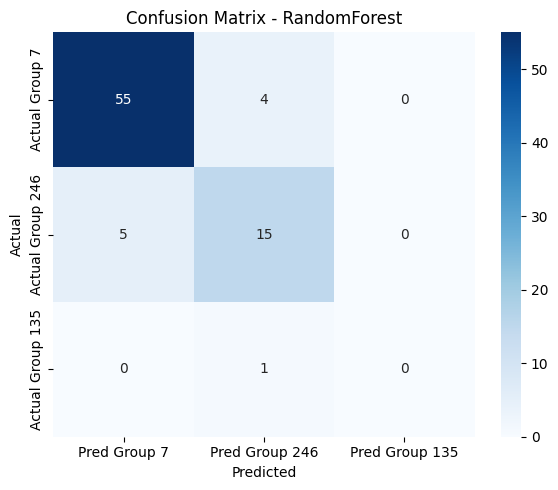

Saved comparison table to 'scenario3_models_comparison.csv'


In [44]:
# Top-level models summary, confusion matrix plot for best top model, and comparison table
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verify required objects
required = ['scenario3_models', 'scenario3_overall']
missing = [r for r in required if r not in globals()]
if missing:
    print('Missing required artifacts:', missing)
    print('Run the Scenario 3 training cells first to generate model metrics.')
else:
    # Build comparison dataframe from scenario3_overall
    comp_df = pd.DataFrame(scenario3_overall)
    # Ensure numeric columns exist and format
    for col in ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']:
        if col not in comp_df.columns:
            comp_df[col] = None
    comp_df = comp_df[['Model', 'Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']]
    comp_df = comp_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

    print('\nTop-level models comparison:')
    display(comp_df.style.format({
        'Accuracy': '{:.3f}',
        'Precision (macro)': '{:.3f}',
        'Recall (macro)': '{:.3f}',
        'F1 (macro)': '{:.3f}'
    }))

    # Print detailed information about each pipeline (steps and final estimator)
    print('\nTop-level model pipelines and final estimators:')
    for name, pipeline in scenario3_models.items():
        print('\nModel:', name)
        try:
            steps = pipeline.steps
        except Exception:
            # If not a Pipeline (some user code may store raw estimators)
            print('  (not a sklearn Pipeline) =>', repr(pipeline))
            continue
        for step_name, estimator in steps:
            print(f'  - step: {step_name} -> {estimator.__class__.__name__}')
        # Show final estimator params (truncate long dicts)
        final_est = steps[-1][1]
        try:
            params = final_est.get_params()
            # show only a short set of param keys to keep output compact
            show_keys = ['n_estimators', 'max_depth', 'C', 'solver', 'class_weight']
            shown = {k: params.get(k) for k in show_keys if k in params}
            print('  Final estimator params (selected):', shown)
        except Exception:
            print('  Could not extract params for final estimator.')

    # Identify best top model
    best_top = comp_df.loc[0, 'Model']
    print(f"\nSelected best top-level model by Accuracy: {best_top}")

    # Plot confusion matrix for the best top model if available
    if 'scenario3_conf_matrices' in globals() and best_top in scenario3_conf_matrices:
        cm_df = scenario3_conf_matrices[best_top]
        print('\nConfusion matrix for best top model:')
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {best_top}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    else:
        print('Confusion matrix for best top model not found; ensure the Scenario 3 cell built `scenario3_conf_matrices`.')

    # Save comparison table to CSV for easy review (optional)
    try:
        comp_df.to_csv('scenario3_models_comparison.csv', index=False)
        print("Saved comparison table to 'scenario3_models_comparison.csv'")
    except Exception:
        pass



Per-label metrics (merged global model):


,precision,recall,f1-score,support
1,1.000000,0.666667,0.800000,3
2,0.955556,0.955556,0.955556,45
4,0.880000,0.785714,0.830189,28
5,1.000000,1.000000,1.000000,3
6,0.800000,0.888889,0.842105,27
7,0.982993,0.986348,0.984668,293



Confusion matrix for merged model:


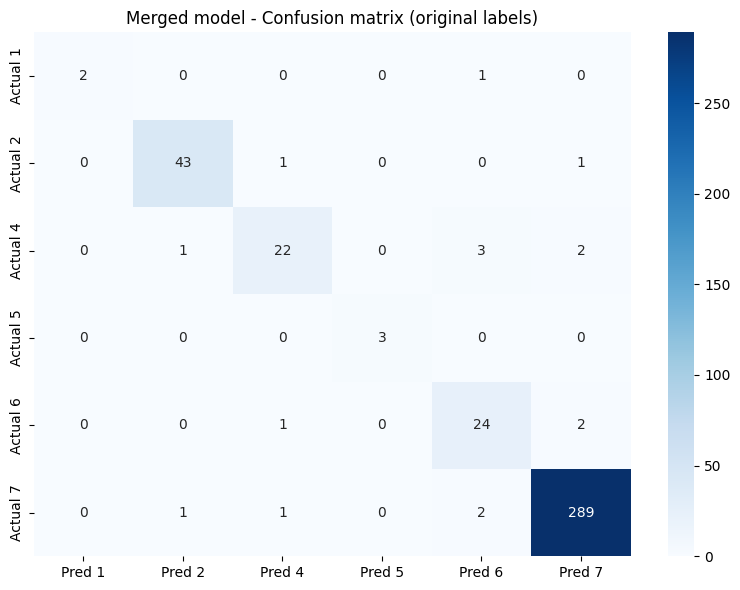


Metrics for each model (top-level and subgroup):


,model,scope,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,subgroup-135,0.5000,NaN,NaN,NaN
1,LogisticRegression,subgroup-135,0.5000,NaN,NaN,NaN
2,XGBoost,subgroup-135,0.5000,NaN,NaN,NaN
3,XGBoost,subgroup-246,0.7000,NaN,NaN,NaN
4,RandomForest,subgroup-246,0.6000,NaN,NaN,NaN
5,LogisticRegression,subgroup-246,0.4500,NaN,NaN,NaN
6,RandomForest,top-level,0.8750,0.555556,0.560734,0.558123
7,XGBoost,top-level,0.8750,0.552769,0.571751,0.561661
8,SVM (RBF),top-level,0.8625,0.541818,0.577119,0.555945
9,LogisticRegression,top-level,0.8375,0.563179,0.554802,0.557540



Selected models mapping:


,label,selected_model,notes
0,Group prediction (top-level),RandomForest,Top-level classifier selected by accuracy
1,"labels 2,4,6",XGBoost,Subgroup model used when top-level returns Gro...
2,"labels 1,3,5",RandomForest,Subgroup model used when top-level returns Gro...



Per-original-label mapping to selected model:


,original_label,group,model_used,notes
0,1,Group 135,RandomForest,Predicted by subgroup-135 model
1,2,Group 246,XGBoost,Predicted by subgroup-246 model
2,4,Group 246,XGBoost,Predicted by subgroup-246 model
3,5,Group 135,RandomForest,Predicted by subgroup-135 model
4,6,Group 246,XGBoost,Predicted by subgroup-246 model
5,7,Group 7,RandomForest,Top-level predicts Group 7 -> label 7


In [45]:
# Detailed per-label information, model metrics table, and label->model mapping
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Check prerequisites
required = ['scenario3_models', 'scenario3_overall', 'scenario3_df']
missing = [r for r in required if r not in globals()]
if missing:
    print('Missing required artifacts:', missing)
    print('Run Scenario 3 training and subgroup training cells first.')
else:
    # Rebuild merged final predictions (same logic as merged-evaluation cell)
    best_top = max(scenario3_overall, key=lambda d: d['Accuracy'])['Model']
    top_model = scenario3_models[best_top]

    # choose subgroup best names if available
    best_246_name = max(results_246.items(), key=lambda kv: kv[1]['accuracy'])[0] if 'results_246' in globals() else None
    best_135_name = max(results_135.items(), key=lambda kv: kv[1]['accuracy'])[0] if 'results_135' in globals() else None

    best_246_model = models_246[best_246_name] if best_246_name and 'models_246' in globals() else None
    best_135_model = models_135[best_135_name] if best_135_name and 'models_135' in globals() else None

    # Prepare evaluation set
    X_all = scenario3_df[feature_columns_s3].copy()
    y_true_raw = clean_numeric(scenario3_df.get('malnutrition_type', pd.Series([np.nan]*len(scenario3_df)))).round()
    mask = y_true_raw.notna()
    X_eval = X_all.loc[mask]
    y_true = y_true_raw.loc[mask].astype(int)

    # Predict groups with top_model
    group_preds = top_model.predict(X_eval)
    final_preds = pd.Series(index=X_eval.index, dtype='Int64')
    idx_to_group = {i: g for i, g in enumerate(group_order)}
    subgroup_feat_cols = [c for c in feature_columns_s3 if c in X_eval.columns]

    # Safe label maps
    idx_to_label_246 = globals().get('idx_to_label_246', None)
    idx_to_label_135 = globals().get('idx_to_label_135', None)

    for grp_idx in np.unique(group_preds):
        grp_name = idx_to_group.get(grp_idx, None)
        idx_mask = group_preds == grp_idx
        idx_index = X_eval.index[idx_mask]
        if grp_name == 'Group 7':
            final_preds.loc[idx_index] = 7
        elif grp_name == 'Group 246' and best_246_model is not None:
            sub_X = X_eval.loc[idx_index, subgroup_feat_cols]
            sub_X_filled = sub_X.fillna(sub_X.median())
            col_meds = X_eval[subgroup_feat_cols].median()
            sub_X_filled = sub_X_filled.fillna(col_meds)
            sub_pred = best_246_model.predict(sub_X_filled)
            mapped = [idx_to_label_246[int(p)] for p in sub_pred]
            final_preds.loc[idx_index] = mapped
        elif grp_name == 'Group 135' and best_135_model is not None:
            sub_X = X_eval.loc[idx_index, subgroup_feat_cols]
            sub_X_filled = sub_X.fillna(sub_X.median())
            col_meds = X_eval[subgroup_feat_cols].median()
            sub_X_filled = sub_X_filled.fillna(col_meds)
            sub_pred = best_135_model.predict(sub_X_filled)
            mapped = [idx_to_label_135[int(p)] for p in sub_pred]
            final_preds.loc[idx_index] = mapped
        else:
            final_preds.loc[idx_index] = pd.NA

    # Evaluate merged predictions
    valid_mask = final_preds.notna()
    y_pred_final = final_preds.loc[valid_mask].astype(int)
    y_true_final = y_true.loc[valid_mask]

    if len(y_pred_final) == 0:
        print('No merged predictions available to evaluate.')
    else:
        # Per-label info (classification report -> DataFrame)
        report_dict = classification_report(y_true_final, y_pred_final, output_dict=True, zero_division=0)
        per_label_df = pd.DataFrame(report_dict).T
        # Keep only label rows (exclude macro/weighted avg rows)
        label_rows = [r for r in per_label_df.index if r not in ('macro avg','weighted avg','accuracy')]
        per_label_df = per_label_df.loc[label_rows]
        # Add support as integer
        per_label_df['support'] = per_label_df['support'].astype(int)

        print('\nPer-label metrics (merged global model):')
        display(per_label_df[['precision','recall','f1-score','support']].sort_index())

        # Confusion matrix plot
        labels_sorted = sorted(y_true_final.unique())
        cm = confusion_matrix(y_true_final, y_pred_final, labels=labels_sorted)
        cm_df = pd.DataFrame(cm, index=[f'Actual {l}' for l in labels_sorted], columns=[f'Pred {l}' for l in labels_sorted])
        print('\nConfusion matrix for merged model:')
        plt.figure(figsize=(8,6))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
        plt.title('Merged model - Confusion matrix (original labels)')
        plt.tight_layout()
        plt.show()

        # Metrics for each model: top-level and subgroup models
        # Top-level comparison table (scenario3_overall)
        top_df = pd.DataFrame(scenario3_overall).set_index('Model')
        top_df = top_df[['Accuracy','Precision (macro)','Recall (macro)','F1 (macro)']].rename(columns={
            'Accuracy':'accuracy_top','Precision (macro)':'precision_macro_top','Recall (macro)':'recall_macro_top','F1 (macro)':'f1_macro_top'
        })

        rows = []
        # add top-level models
        for model_name, row in top_df.iterrows():
            rows.append({'model': model_name, 'scope':'top-level', 'accuracy': row['accuracy_top'], 'precision_macro': row['precision_macro_top'], 'recall_macro': row['recall_macro_top'], 'f1_macro': row['f1_macro_top']})

        # add subgroup metrics
        if 'results_246' in globals():
            for mname, minfo in results_246.items():
                rows.append({'model': mname, 'scope':'subgroup-246', 'accuracy': min(minfo.get('accuracy', np.nan),1.0), 'precision_macro': np.nan, 'recall_macro': np.nan, 'f1_macro': np.nan})
        if 'results_135' in globals():
            for mname, minfo in results_135.items():
                rows.append({'model': mname, 'scope':'subgroup-135', 'accuracy': min(minfo.get('accuracy', np.nan),1.0), 'precision_macro': np.nan, 'recall_macro': np.nan, 'f1_macro': np.nan})

        models_metrics_df = pd.DataFrame(rows).sort_values(['scope','accuracy'], ascending=[True, False]).reset_index(drop=True)
        print('\nMetrics for each model (top-level and subgroup):')
        display(models_metrics_df)

        # Which model is selected
        selected = []
        selected.append({'label': 'Group prediction (top-level)', 'selected_model': best_top, 'notes':'Top-level classifier selected by accuracy'})
        if best_246_name:
            selected.append({'label': 'labels 2,4,6', 'selected_model': best_246_name, 'notes':'Subgroup model used when top-level returns Group 246'})
        else:
            selected.append({'label': 'labels 2,4,6', 'selected_model': None, 'notes':'No subgroup model available'})
        if best_135_name:
            selected.append({'label': 'labels 1,3,5', 'selected_model': best_135_name, 'notes':'Subgroup model used when top-level returns Group 135'})
        else:
            selected.append({'label': 'labels 1,3,5', 'selected_model': None, 'notes':'No subgroup model available'})
        selected_df = pd.DataFrame(selected)
        print('\nSelected models mapping:')
        display(selected_df)

        # Finally, map each original label to the model used for that label
        label_map_rows = []
        unique_labels = sorted(y_true_final.unique())
        for lbl in unique_labels:
            if lbl == 7:
                label_map_rows.append({'original_label': lbl, 'group': 'Group 7', 'model_used': best_top, 'notes':'Top-level predicts Group 7 -> label 7'})
            elif lbl in (2,4,6):
                label_map_rows.append({'original_label': lbl, 'group': 'Group 246', 'model_used': best_246_name, 'notes':'Predicted by subgroup-246 model'})
            elif lbl in (1,3,5):
                label_map_rows.append({'original_label': lbl, 'group': 'Group 135', 'model_used': best_135_name, 'notes':'Predicted by subgroup-135 model'})
            else:
                label_map_rows.append({'original_label': lbl, 'group': 'Unknown', 'model_used': best_top, 'notes':'Fallback to top-level'})
        label_map_df = pd.DataFrame(label_map_rows)
        print('\nPer-original-label mapping to selected model:')
        display(label_map_df)


Selected top-level model: RandomForest

Top-level model classification report (groups):
              precision    recall  f1-score   support

     Group 7       0.98      0.99      0.98       293
   Group 246       0.95      0.95      0.95       100
   Group 135       1.00      0.83      0.91         6

    accuracy                           0.97       399
   macro avg       0.98      0.92      0.95       399
weighted avg       0.97      0.97      0.97       399



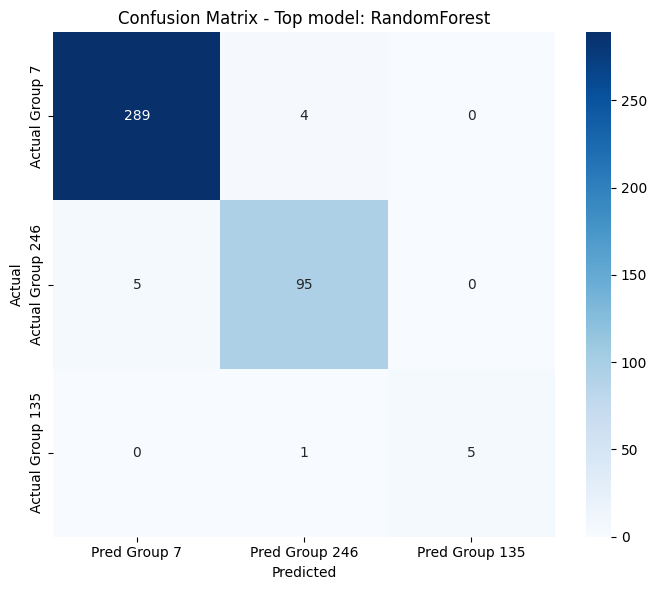

C:\Users\Win 10\AppData\Local\Temp\ipykernel_14552\1493613039.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10')


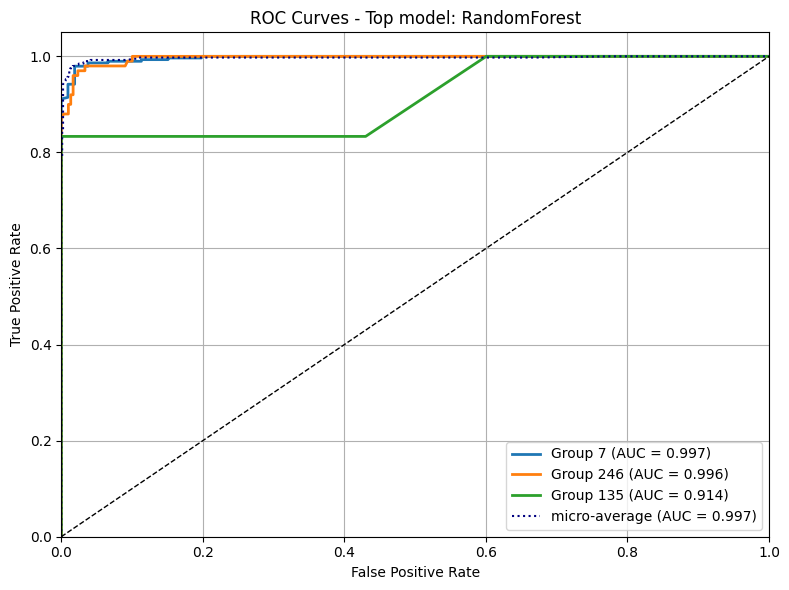

In [46]:
# Confusion matrix and ROC curves for the selected top-level model (group classifier)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

required = ['scenario3_models', 'scenario3_overall', 'scenario3_df', 'feature_columns_s3', 'group_order']
missing = [r for r in required if r not in globals()]
if missing:
    print('Missing required artifacts:', missing)
    print('Run Scenario 3 training and preparations first.')
else:
    # Select best top-level model
    best_top = max(scenario3_overall, key=lambda d: d['Accuracy'])['Model']
    top_model = scenario3_models[best_top]
    print(f"Selected top-level model: {best_top}")

    # Prepare evaluation set (use rows with known group labels)
    df = scenario3_df.copy()
    # Derive group index if needed
    if 'group_idx' in df.columns:
        y_group = df['group_idx']
    elif 'malnutrition_group' in df.columns:
        grp_to_idx = {g: i for i, g in enumerate(group_order)}
        y_group = df['malnutrition_group'].map(grp_to_idx)
    else:
        raise RuntimeError('scenario3_df lacks group information (group_idx or malnutrition_group)')

    mask = y_group.notna()
    if mask.sum() == 0:
        print('No rows with known group labels found in scenario3_df to evaluate.')
    else:
        X_eval = df.loc[mask, feature_columns_s3]
        y_true = y_group.loc[mask].astype(int)

        # Confusion matrix & classification report
        try:
            y_pred = top_model.predict(X_eval)
        except Exception as e:
            # try imputing missing values and predict again
            X_eval_imp = X_eval.fillna(X_eval.median())
            y_pred = top_model.predict(X_eval_imp)
            X_eval = X_eval_imp

        labels = list(range(len(group_order)))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=[f'Actual {g}' for g in group_order], columns=[f'Pred {g}' for g in group_order])

        print('\nTop-level model classification report (groups):')
        print(classification_report(y_true, y_pred, target_names=group_order, zero_division=0))

        plt.figure(figsize=(7,6))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Top model: {best_top}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

        # ROC curves (one-vs-rest) if probabilities or decision_function available
        n_classes = len(group_order)
        y_true_bin = label_binarize(y_true, classes=labels)

        y_score = None
        try:
            if hasattr(top_model, 'predict_proba'):
                y_score = top_model.predict_proba(X_eval)
            elif hasattr(top_model, 'decision_function'):
                y_score = top_model.decision_function(X_eval)
                if y_score.ndim == 1:
                    y_score = np.vstack([1 - y_score, y_score]).T
        except Exception:
            # attempt with imputed features
            X_eval_imp = X_eval.fillna(X_eval.median())
            try:
                if hasattr(top_model, 'predict_proba'):
                    y_score = top_model.predict_proba(X_eval_imp)
                    X_eval = X_eval_imp
                elif hasattr(top_model, 'decision_function'):
                    y_score = top_model.decision_function(X_eval_imp)
                    if y_score.ndim == 1:
                        y_score = np.vstack([1 - y_score, y_score]).T
                    X_eval = X_eval_imp
            except Exception as e:
                y_score = None

        if y_score is None:
            print('\nTop model does not provide probabilities or scores usable for ROC; skipping ROC plots.')
        else:
            # If predict_proba for multi-class might return list of arrays for OneVsRest wrappers; ensure shape
            if isinstance(y_score, list):
                # convert list-of-arrays to array
                y_score = np.array(y_score).T

            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i in range(n_classes):
                try:
                    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                    roc_auc[i] = auc(fpr[i], tpr[i])
                except Exception:
                    fpr[i], tpr[i], roc_auc[i] = None, None, np.nan

            # micro-average
            try:
                fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
                roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])
            except Exception:
                fpr['micro'], tpr['micro'], roc_auc['micro'] = None, None, np.nan

            # Plot ROC curves
            plt.figure(figsize=(8, 6))
            colors = plt.cm.get_cmap('tab10')
            for i, grp in enumerate(group_order):
                if fpr.get(i) is not None:
                    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2, label=f'{grp} (AUC = {roc_auc[i]:.3f})')
            if fpr.get('micro') is not None:
                plt.plot(fpr['micro'], tpr['micro'], color='navy', linestyle=':', label=f'micro-average (AUC = {roc_auc["micro"]:.3f})')
            plt.plot([0, 1], [0, 1], 'k--', lw=1)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curves - Top model: {best_top}')
            plt.legend(loc='lower right')
            plt.grid(True)
            plt.tight_layout()
            plt.show()


## Confusion matrices and classification report for `top_model`

This cell computes and plots a confusion matrix per label and prints a classification report. It expects `top_model`, `X_test`, and `y_test` (or `scenario3_df`) to already exist in the kernel.

In [48]:
# Confusion matrices + classification report for top_model (original labels)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prefer explicit objects if present
if 'top_model' not in globals():
    raise NameError("top_model not found in the kernel. Please (re)define or load it before running this cell.")

# Determine evaluation X/y (use X_test/y_test if available, else build from scenario3_df)
if 'X_test' in globals() and 'y_test' in globals():
    X_eval = X_test
    y_true = y_test if not isinstance(y_test, (pd.DataFrame, pd.Series)) else y_test
else:
    # fall back to scenario3_df if present
    if 'scenario3_df' not in globals():
        raise RuntimeError("Neither X_test/y_test nor scenario3_df are available for evaluation.")
    df = scenario3_df.copy()
    if 'malnutrition_type' in df.columns:
        y_true = clean_numeric(df['malnutrition_type']).round().astype(int)
    elif 'group_idx' in df.columns:
        y_true = df['group_idx'].astype(int)
    else:
        raise RuntimeError('scenario3_df lacks malnutrition_type or group_idx for evaluation')
    # Features: try feature_columns_s3 then numeric columns
    if 'feature_columns_s3' in globals():
        # Extract feature names from Pipeline model
        exclude_cols = {'malnutrition_type', 'group_idx', 'malnutrition_group'}
        
        # Get expected features from the model
        model_features = None
        if 'top_model' in globals() and hasattr(top_model, 'steps'):
            # Pipeline: get features from first step (imputer)
            first_step = top_model.steps[0][1]
            if hasattr(first_step, 'feature_names_in_'):
                model_features = list(first_step.feature_names_in_)
        elif 'top_model' in globals() and hasattr(top_model, 'feature_names_in_'):
            # Direct estimator
            model_features = list(top_model.feature_names_in_)
        
        # Use model features if available, otherwise fall back to feature_columns_s3
        if model_features:
            available_cols = [col for col in model_features if col in df.columns and col not in exclude_cols]
        else:
            # Fallback: use feature_columns_s3, excluding non-feature columns
            available_cols = [col for col in feature_columns_s3 if col in df.columns and col not in exclude_cols]
        
        X_eval = df[available_cols].copy()
    else:
        X_eval = df.select_dtypes(include=[np.number]).drop(columns=['malnutrition_type','group_idx'], errors='ignore')

# Get point predictions (try predict, fallback to imputed predict)
try:
    y_pred = top_model.predict(X_eval)
except Exception:
    X_imp = X_eval.fillna(X_eval.median())
    y_pred = top_model.predict(X_imp)
    X_eval = X_imp

# If y_true is a DataFrame with multiple targets, try to pick the right column
if isinstance(y_true, (pd.DataFrame, pd.Series)):
    y_true_arr = np.asarray(y_true).ravel()
else:
    y_true_arr = np.asarray(y_true)

labels = np.unique(np.concatenate([y_true_arr, np.asarray(y_pred)]))
labels_sorted = np.sort(labels)

print("\nClassification report for top_model (on evaluation set):\n")
try:
    print(classification_report(y_true_arr, y_pred, labels=labels_sorted, zero_division=0))
except Exception as e:
    print('Failed to compute classification report:', e)

# Plot binary confusion matrix per label
import math
n_labels = len(labels_sorted)
ncols = min(3, n_labels)
nrows = math.ceil(n_labels / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes_list = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, lbl in enumerate(labels_sorted):
    ax = axes_list[i]
    y_true_bin = (y_true_arr == lbl).astype(int)
    y_pred_bin = (np.asarray(y_pred) == lbl).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'not_{lbl}', f'is_{lbl}'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Label {lbl} (binary)')

# hide extra axes
for j in range(n_labels, len(axes_list)):
    try:
        axes_list[j].axis('off')
    except Exception:
        pass

plt.tight_layout()
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- BMI_12m_zscore
- BMI_12m_zscore_Imputation
- BMI_18m_zscore
- BMI_18m_zscore_Imputation
- BMI_24m_zscore
- ...


## ROC curves (one-vs-rest) for `top_model` per label

This cell will attempt to compute per-label ROC curves. It looks for `predict_proba` or `decision_function` on `top_model`. If neither is available it will skip ROC plotting and print a message.

In [49]:
# ROC (one-vs-rest) per label for top_model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

if 'top_model' not in globals():
    raise NameError("top_model not found in the kernel. Please (re)define or load it before running this cell.")

# Build evaluation set same as the confusion cell
if 'X_test' in globals() and 'y_test' in globals():
    X_eval = X_test
    y_true = y_test if not isinstance(y_test, (pd.DataFrame, pd.Series)) else y_test
else:
    if 'scenario3_df' not in globals():
        raise RuntimeError("Neither X_test/y_test nor scenario3_df are available for ROC evaluation.")
    df = scenario3_df.copy()
    if 'malnutrition_type' in df.columns:
        y_true = clean_numeric(df['malnutrition_type']).round().astype(int)
    elif 'group_idx' in df.columns:
        y_true = df['group_idx'].astype(int)
    else:
        raise RuntimeError('scenario3_df lacks malnutrition_type or group_idx for evaluation')
    if 'feature_columns_s3' in globals():
        # Extract feature names from Pipeline model
        exclude_cols = {'malnutrition_type', 'group_idx', 'malnutrition_group'}
        
        # Get expected features from the model
        model_features = None
        if 'top_model' in globals() and hasattr(top_model, 'steps'):
            # Pipeline: get features from first step (imputer)
            first_step = top_model.steps[0][1]
            if hasattr(first_step, 'feature_names_in_'):
                model_features = list(first_step.feature_names_in_)
        elif 'top_model' in globals() and hasattr(top_model, 'feature_names_in_'):
            # Direct estimator
            model_features = list(top_model.feature_names_in_)
        
        # Use model features if available, otherwise fall back to feature_columns_s3
        if model_features:
            available_cols = [col for col in model_features if col in df.columns and col not in exclude_cols]
        else:
            # Fallback: use feature_columns_s3, excluding non-feature columns
            available_cols = [col for col in feature_columns_s3 if col in df.columns and col not in exclude_cols]
        
        X_eval = df[available_cols].copy()
    else:
        X_eval = df.select_dtypes(include=[np.number]).drop(columns=['malnutrition_type','group_idx'], errors='ignore')

y_true_arr = np.asarray(y_true).ravel()
labels = np.unique(y_true_arr)
n_labels = len(labels)

# Obtain probability-like scores
y_score = None
if hasattr(top_model, 'predict_proba'):
    try:
        y_score = top_model.predict_proba(X_eval)
    except Exception as e:
        print('predict_proba exists but failed:', e)
        y_score = None
elif hasattr(top_model, 'decision_function'):
    try:
        y_score = top_model.decision_function(X_eval)
        if y_score.ndim == 1:
            y_score = np.vstack([1 - y_score, y_score]).T
    except Exception as e:
        print('decision_function exists but failed:', e)
        y_score = None

if y_score is None:
    print("No probability/score output available on top_model — skipping ROC curves. Consider enabling probability=True for models like SVC or using a calibrated classifier.")
else:
    # Binarize true labels for one-vs-rest
    y_true_b = label_binarize(y_true_arr, classes=labels)
    # Align columns if top_model has classes_ attribute
    if hasattr(top_model, 'classes_') and y_score.shape[1] == len(top_model.classes_):
        try:
            col_order = [list(top_model.classes_).index(c) for c in labels]
            y_score = y_score[:, col_order]
        except ValueError:
            pass

    plt.figure(figsize=(8, 6))
    for i, lbl in enumerate(labels):
        try:
            fpr, tpr, _ = roc_curve(y_true_b[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'Label {lbl} (AUC = {roc_auc:.3f})')
        except Exception as e:
            print(f'Could not compute ROC for label {lbl}:', e)
            continue

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves (one-vs-rest) for top_model')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

predict_proba exists but failed: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- BMI_12m_zscore
- BMI_12m_zscore_Imputation
- BMI_18m_zscore
- BMI_18m_zscore_Imputation
- BMI_24m_zscore
- ...

No probability/score output available on top_model — skipping ROC curves. Consider enabling probability=True for models like SVC or using a calibrated classifier.
